# Notebook 2: Market Geography

**Where are the German data jobs, and how does the market differ between cities and regions?**

Built on the dataset from `01_skills_landscape.ipynb` (Bundesagentur API, May 2026, n≈2,300).
This notebook answers:

1. **How concentrated is the German data job market geographically?** (HHI + top-K share)
2. **Are some cities more international-friendly than others?** (language × city, with effect size)
3. **Which cities are unusually remote-friendly?** (outlier detection)
4. **Which Bundesländer welcome career changers?** (Quereinstieg by region)
5. **Does Frankfurt really skew BI/SQL? Does Munich really skew ML?** (skill demand by city)
6. **How does the role mix vary across hubs?** (DS/DA/DE/ML composition by city)

### Methodological notes

- We restrict statistical comparisons to cities with **n ≥ 30 postings** to avoid noise.
- City names like "Nürnberg, Mittelfranken" and "Karlsruhe, Baden" are normalized to the city alone.
- Role classification uses Bundesagentur's `hauptberuf` field (same mapping as notebook 1), not title regex.
- `homeoffice_allowed` is NULL for ~47% of postings (employers don't always declare). We report the percentage among *known* values and surface the N.

## 1. Setup and Master Query

In [1]:
from __future__ import annotations
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

We pull everything we need into one DataFrame so downstream cells don't keep hitting DuckDB. The query joins `jobs_extracted` + `jobs_clean` and materializes a clean lowercase skill array per job in SQL — much cheaper than doing it in pandas.

In [2]:
DB_PATH = "~/de-data-jobs-2026/data/db/jobs.duckdb"
conn = duckdb.connect(DB_PATH, read_only=True)

query = """
    WITH unnested_skills AS (
        SELECT refnr, LOWER(UNNEST(required_skills::VARCHAR[])) AS skill_lower
        FROM jobs_extracted
    ),
    grouped_skills AS (
        SELECT refnr, LIST(skill_lower) AS skills_norm
        FROM unnested_skills
        GROUP BY refnr
    )
    SELECT
        c.refnr,
        c.clean_title,
        c.hauptberuf,
        c.city,
        c.bundesland,
        c.latitude,
        c.longitude,
        c.language AS posting_language,
        c.homeoffice_allowed,
        c.quereinstieg_friendly,
        e.seniority_label,
        g.skills_norm
    FROM jobs_extracted e
    JOIN jobs_clean c USING(refnr)
    LEFT JOIN grouped_skills g USING(refnr)
    WHERE c.city IS NOT NULL AND c.city != ''
"""
df = conn.execute(query).df()
print(f"Loaded {len(df):,} postings")

Loaded 2,314 postings


### Normalize cities and Bundesländer

Bundesagentur returns names like `Nürnberg, Mittelfranken` (city + administrative region) and `BAYERN` (state in uppercase). We normalize to the city stem and proper-case the state.

In [3]:
df["city_norm"] = df["city"].str.split(",").str[0].str.strip()

# Bundesland names ("NORDRHEIN-WESTFALEN" - "Nordrhein-Westfalen")
df["bundesland_norm"] = (
    df["bundesland"]
    .str.lower()
    .str.replace("-", "-", regex=False)
    .apply(lambda s: "-".join(part.capitalize() for part in str(s).split("-")) if pd.notna(s) else s)
)

SKILL_ALIASES = {
    "ml": "machine learning",
    "ai": "artificial intelligence",
    "ki": "artificial intelligence",
    "künstliche intelligenz": "artificial intelligence",
    "maschinelles lernen": "machine learning",
    "powerbi": "power bi",
    "power-bi": "power bi",
    "microsoft power bi": "power bi",
    "amazon web services": "aws",
    "google cloud platform": "gcp",
    "google cloud": "gcp",
    "microsoft azure": "azure",
    "sklearn": "scikit-learn",
    "scikit learn": "scikit-learn",
    "datenanalyse": "data analysis",
    "dataanalyse": "data analysis",
    "datenmodellierung": "data modeling",
    "large language models": "llm",
    "llms": "llm",
}

def normalize_skills(skill_list):
    if not isinstance(skill_list, (list, np.ndarray)):
        return []
    return [SKILL_ALIASES.get(s.strip().lower(), s.strip().lower()) 
            for s in skill_list if isinstance(s, str)]

df["skills_norm"] = df["skills_norm"].apply(normalize_skills)

print(f"Unique cities: {df['city_norm'].nunique()}")
print(f"Unique Bundesländer: {df['bundesland_norm'].nunique()}")
df[["city_norm", "bundesland_norm", "latitude", "longitude"]].head()

Unique cities: 425
Unique Bundesländer: 16


,city_norm,bundesland_norm,latitude,longitude
0,Berlin,Berlin,52.524756,13.393031
1,Berlin,Berlin,52.544565,13.267391
2,Berlin,Berlin,52.517272,13.388290
3,Wolfsburg,Niedersachsen,52.419318,10.770824
4,Berlin,Berlin,52.520733,13.328015


## 2. Market Concentration

**Question:** Is the German data job market geographically concentrated, or spread across many cities?

We use two metrics:

- **Top-K share**: percentage of all postings in the top 3 / top 10 cities. Intuitive but coarse.
- **Herfindahl-Hirschman Index (HHI)**: sum of squared market shares. The standard concentration measure from competition economics, also widely used for geographic concentration. Interpretation thresholds (US DOJ guidelines):
  - HHI < 1,500: competitive / dispersed
  - 1,500–2,500: moderately concentrated
  - HHI > 2,500: highly concentrated

In [4]:
city_counts = df["city_norm"].value_counts()
total_jobs = city_counts.sum()
city_shares = (city_counts / total_jobs) * 100

# Concentration matrix
hhi = (city_shares ** 2).sum()
top_3_share = city_shares.head(3).sum()
top_5_share = city_shares.head(5).sum()
top_10_share = city_shares.head(10).sum()

# Verdict on HHI
if hhi < 1500:
    hhi_verdict = "competitive / dispersed"
elif hhi < 2500:
    hhi_verdict = "moderately concentrated"
else:
    hhi_verdict = "highly concentrated"

print(f"Total cities with at least 1 posting: {len(city_counts):,}")
print(f"Top 3 city market share:  {top_3_share:5.1f}%")
print(f"Top 5 city market share:  {top_5_share:5.1f}%")
print(f"Top 10 city market share: {top_10_share:5.1f}%")
print()
print(f"HHI = {hhi:.0f} - {hhi_verdict}")

Total cities with at least 1 posting: 425
Top 3 city market share:   23.4%
Top 5 city market share:   31.5%
Top 10 city market share:  43.9%

HHI = 284 - competitive / dispersed


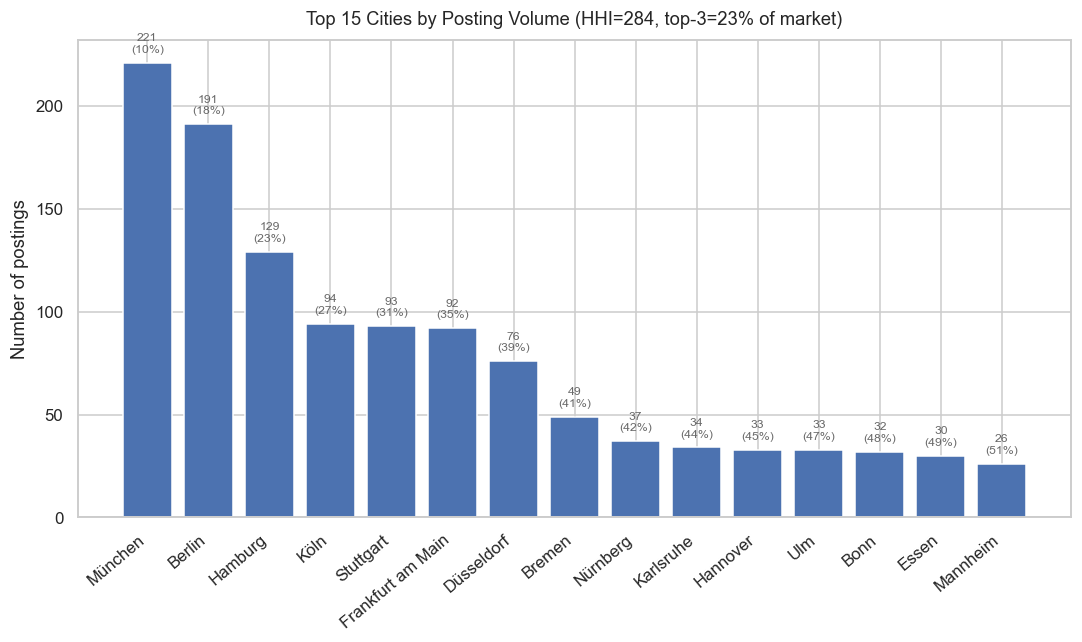

In [5]:
top_15 = city_counts.head(15)
cum_share = (top_15.cumsum() / total_jobs * 100)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(top_15)), top_15.values, color="#4C72B0")
ax.set_xticks(range(len(top_15)))
ax.set_xticklabels(top_15.index, rotation=40, ha="right")
ax.set_ylabel("Number of postings")
ax.set_title(f"Top 15 Cities by Posting Volume (HHI={hhi:.0f}, top-3={top_3_share:.0f}% of market)", pad=10)

for i, (bar, n, cum) in enumerate(zip(bars, top_15.values, cum_share)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{n}\n({cum:.0f}%)", ha="center", fontsize=8, color="dimgray")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_15_cities.png")
plt.show()

## 3. Geographic Distribution

A bubble map of postings across Germany. Bubble size = posting count. Bubble color = % English-language postings in that city — so the map encodes both *where the jobs are* and *how international-friendly each city is* on a single chart.

Map bounds are set to Germany's geographic extent (roughly 5.5°-15.5°E, 47°-55°N).

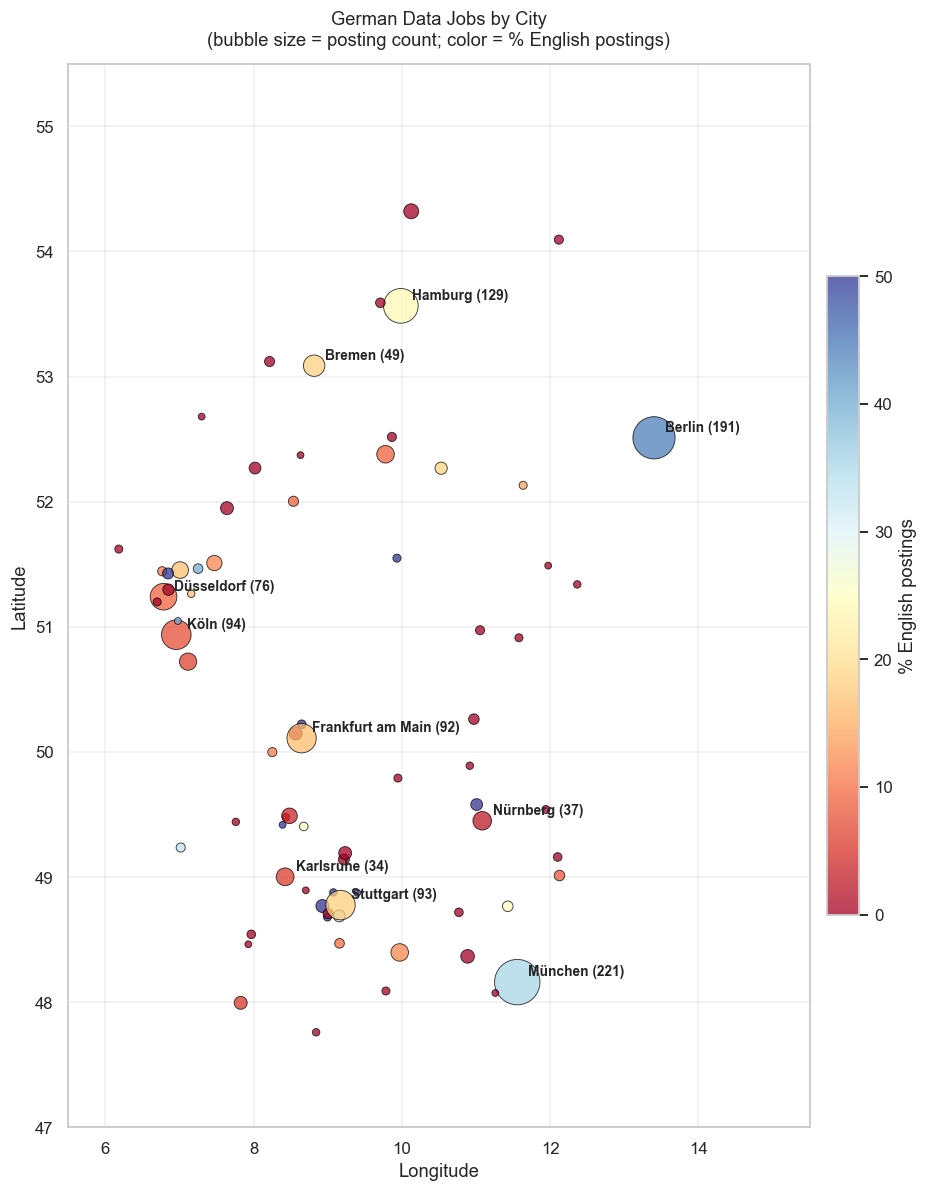

In [6]:
# Agg. by city
city_agg = (
    df.dropna(subset=["latitude", "longitude"])
    .groupby("city_norm")
    .agg(
        n_jobs=("refnr", "count"),
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        pct_english=("posting_language", lambda x: 100 * (x == "en").sum() / len(x)),
    )
    .reset_index()
)
city_agg = city_agg[city_agg["n_jobs"] >= 5]

fig, ax = plt.subplots(figsize=(9, 11))
scatter = ax.scatter(
    city_agg["longitude"],
    city_agg["latitude"],
    s=city_agg["n_jobs"] * 4,
    c=city_agg["pct_english"],
    cmap="RdYlBu",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.6,
    vmin=0, vmax=50,
)

ax.set_xlim(5.5, 15.5)
ax.set_ylim(47, 55.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("German Data Jobs by City\n(bubble size = posting count; color = % English postings)", pad=12)

top_10 = city_agg.nlargest(10, "n_jobs")
for _, row in top_10.iterrows():
    ax.annotate(
        f'{row["city_norm"]} ({row["n_jobs"]})',
        (row["longitude"], row["latitude"]),
        xytext=(7, 4), textcoords="offset points",
        fontsize=9, fontweight="bold",
    )

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("% English postings")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "city_map.png")
plt.show()

## 4. Language Accessibility by City

**Question:** Is the language of postings systematically different by city, or is it noise?

We restrict to cities with **n ≥ 30** for statistical viability, then run a chi-square test of independence (`city × posting language`).

A p-value alone isn't enough at this sample size — with n=2,331, even tiny differences will be "significant." We also compute **Cramer's V** (effect size), which is bounded [0, 1]:

- V < 0.1: negligible association
- 0.1 ≤ V < 0.3: weak
- 0.3 ≤ V < 0.5: moderate
- V ≥ 0.5: strong

In [7]:
MIN_N = 30
valid_cities = city_counts[city_counts >= MIN_N].index
df_lang = df[df["city_norm"].isin(valid_cities) & df["posting_language"].notna()].copy()

# Chi-square test of independence
lang_crosstab = pd.crosstab(df_lang["city_norm"], df_lang["posting_language"])
chi2, p, dof, expected = chi2_contingency(lang_crosstab)
n_total = lang_crosstab.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(lang_crosstab.shape) - 1)))

print(f"Chi-square test: city × language")
print(f"  Chi2     = {chi2:.2f}")
print(f"  dof      = {dof}")
print(f"  p-value  = {p:.2e}")
print(f"  Cramer V = {cramers_v:.3f}  ", end="")
if cramers_v < 0.1: print("(negligible)")
elif cramers_v < 0.3: print("(weak)")
elif cramers_v < 0.5: print("(moderate)")
else: print("(strong)")

Chi-square test: city × language
  Chi2     = 116.69
  dof      = 13
  p-value  = 9.06e-19
  Cramer V = 0.319  (moderate)


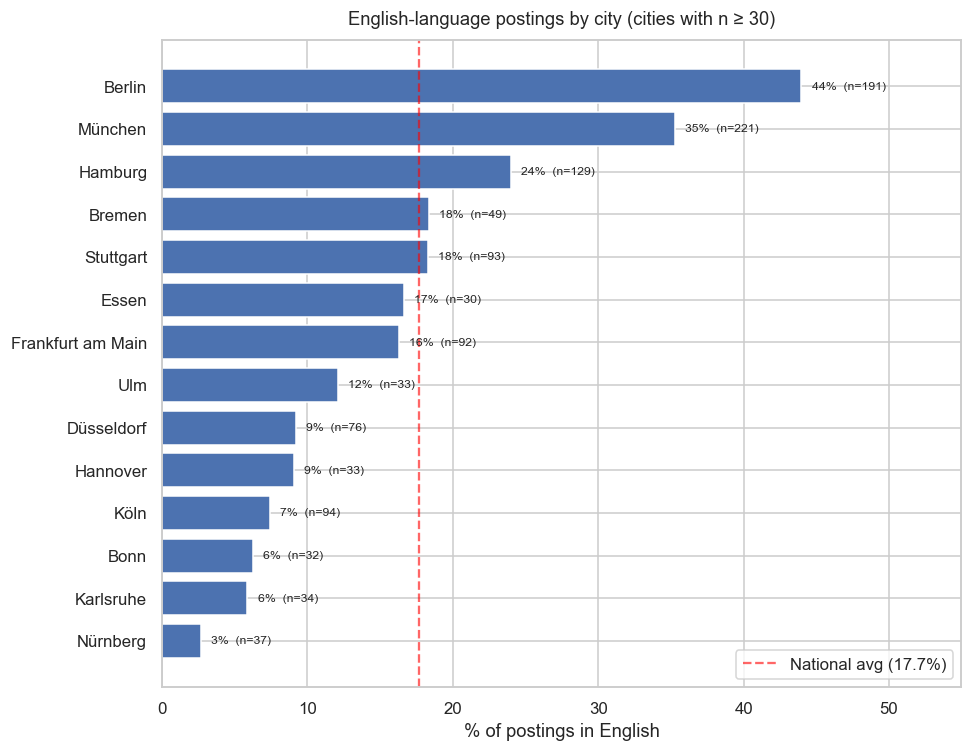

In [8]:
# % English by city, sorted
english_share = (
    pd.crosstab(df_lang["city_norm"], df_lang["posting_language"], normalize="index") * 100
).get("en", pd.Series()).sort_values()
english_share_df = english_share.reset_index()
english_share_df.columns = ["city", "pct_english"]

english_share_df["n"] = english_share_df["city"].map(city_counts)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(english_share_df["city"], english_share_df["pct_english"], color="#4C72B0")
overall_pct = 100 * (df["posting_language"] == "en").mean()
ax.axvline(overall_pct, color="red", linestyle="--", alpha=0.6, label=f"National avg ({overall_pct:.1f}%)")

ax.set_xlabel("% of postings in English")
ax.set_title("English-language postings by city (cities with n ≥ 30)", pad=10)
ax.legend(loc="lower right")

for bar, pct, n in zip(bars, english_share_df["pct_english"], english_share_df["n"]):
    ax.text(bar.get_width() + 0.7, bar.get_y() + bar.get_height()/2,
            f"{pct:.0f}%  (n={n})", va="center", fontsize=8)

ax.set_xlim(0, english_share_df["pct_english"].max() * 1.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "english_by_city.png")
plt.show()

**Notes for the writeup:**

- Compare each city to the national average (red dashed line). Which cities are notably *above* it? Notably *below*?
- The contrast between the most-English city and the least-English city is your "city-level language gap" finding.
- The Cramer's V tells you whether this geographic split is a real signal or just statistical noise inflated by sample size.

## 5. Remote Friendliness by City

**Question:** Are some cities meaningfully more remote-friendly than others?

A caveat to surface honestly: **`homeoffice_allowed` is NULL for ~47% of postings** because not all employers declare a remote policy. We report the % among postings that *do* declare, plus the N of known values per city, so readers can judge.

Outlier detection: with only ~14 cities at n ≥ 30, parametric z-scores are unreliable. We use a rank-based approach instead — surface cities more than 1.5× the inter-quartile range from the median.

In [9]:
df_remote = df[df["city_norm"].isin(valid_cities) & df["homeoffice_allowed"].notna()].copy()

remote_stats = (
    df_remote.groupby("city_norm")["homeoffice_allowed"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "pct_remote", "count": "n_known"})
)
remote_stats["pct_remote"] *= 100
remote_stats = remote_stats.sort_values("pct_remote")

# IQR-based outlier detection (more robust than z-score on small N)
q1, q3 = remote_stats["pct_remote"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
remote_stats["is_outlier"] = (remote_stats["pct_remote"] < lower_fence) | (remote_stats["pct_remote"] > upper_fence)

print(f"Median remote-allowed: {remote_stats['pct_remote'].median():.1f}%")
print(f"IQR fences: [{lower_fence:.1f}, {upper_fence:.1f}]")
print()
print("Outlier cities:")
print(remote_stats[remote_stats["is_outlier"]])

Median remote-allowed: 32.1%
IQR fences: [2.0, 57.4]

Outlier cities:
           pct_remote  n_known  is_outlier
city_norm                                 
Nürnberg    57.894737       19        True


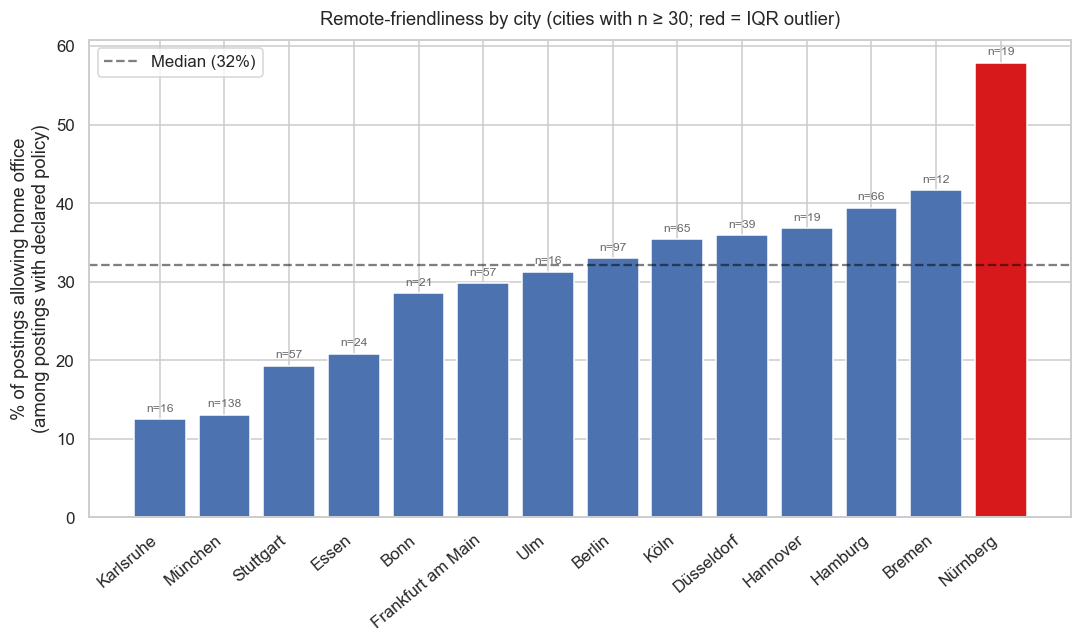

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#D7191C" if outlier else "#4C72B0" for outlier in remote_stats["is_outlier"]]
bars = ax.bar(remote_stats.index, remote_stats["pct_remote"], color=colors)

median_remote = remote_stats["pct_remote"].median()
ax.axhline(median_remote, color="black", linestyle="--", alpha=0.5, label=f"Median ({median_remote:.0f}%)")

ax.set_ylabel("% of postings allowing home office\n(among postings with declared policy)")
ax.set_title("Remote-friendliness by city (cities with n ≥ 30; red = IQR outlier)", pad=10)
plt.xticks(rotation=40, ha="right")

for bar, n in zip(bars, remote_stats["n_known"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"n={n}", ha="center", fontsize=8, color="dimgray")

ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "remote_by_city.png")
plt.show()

## 6. Career-Changer Friendliness by Bundesland

We aggregate Quereinstieg flags to the Bundesland level because city-level Ns get too small to detect a 1-2% effect reliably. Same MIN_N = 30 cutoff applies, computed against postings with non-null flags.

Recall the national finding: only 1.4% of postings are flagged as Quereinstieg-friendly. I'm looking for which regions deviate from that baseline.

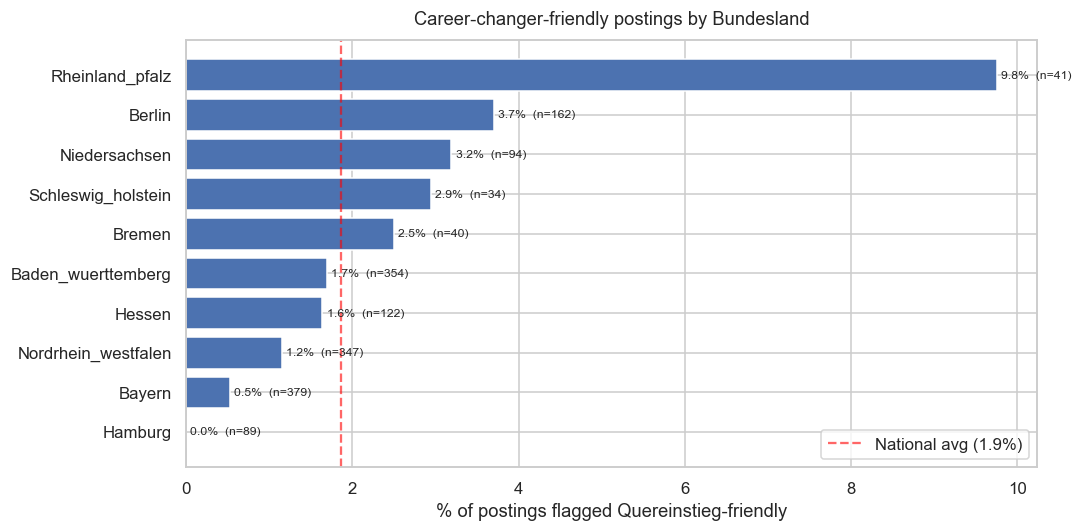

In [11]:
df_quer = df[df["quereinstieg_friendly"].notna()].copy()
state_counts = df_quer["bundesland_norm"].value_counts()
valid_states = state_counts[state_counts >= 30].index

quer_stats = (
    df_quer[df_quer["bundesland_norm"].isin(valid_states)]
    .groupby("bundesland_norm")["quereinstieg_friendly"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "pct_quereinstieg", "count": "n_known"})
)
quer_stats["pct_quereinstieg"] *= 100
quer_stats = quer_stats.sort_values("pct_quereinstieg")

national_pct = 100 * df_quer["quereinstieg_friendly"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(quer_stats.index, quer_stats["pct_quereinstieg"], color="#4C72B0")
ax.axvline(national_pct, color="red", linestyle="--", alpha=0.6, label=f"National avg ({national_pct:.1f}%)")

ax.set_xlabel("% of postings flagged Quereinstieg-friendly")
ax.set_title("Career-changer-friendly postings by Bundesland", pad=10)

for bar, pct, n in zip(bars, quer_stats["pct_quereinstieg"], quer_stats["n_known"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%  (n={n})", va="center", fontsize=8)

ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "quereinstieg_by_bundesland.png")
plt.show()

## 7. Skill Demand by City

**Question:** Is Frankfurt actually SQL/BI-heavy because of finance? Is Munich actually more ML-heavy?

I restrict to the top 6 cities by posting volume and the top 12 globally-demanded skills. For each city I show the % of *that city's* postings that mention each skill (row-normalized).

We also compute a **regional differentiation index** per city: the sum of absolute differences between city-level skill % and national skill % across the top skills. Higher = more atypical skill profile.

In [12]:
TOP_N_CITIES = 6
TOP_N_SKILLS = 12

top_cities = city_counts.head(TOP_N_CITIES).index.tolist()
df_top_cities = df[df["city_norm"].isin(top_cities)].copy()

df_skills = df_top_cities.explode("skills_norm").dropna(subset=["skills_norm"]).reset_index(drop=True)
all_skills_exploded = df.explode("skills_norm").dropna(subset=["skills_norm"]).reset_index(drop=True)

# Pick top skills globally (not just in top cities — avoids bias)
top_skills = (
    all_skills_exploded["skills_norm"].value_counts().head(TOP_N_SKILLS).index.tolist()
)

df_skills_filtered = df_skills[df_skills["skills_norm"].isin(top_skills)]

skill_city_matrix = (
    pd.crosstab(
        df_skills_filtered["city_norm"],
        df_skills_filtered["skills_norm"],
    )
    .div(df_top_cities["city_norm"].value_counts(), axis=0)  # divide by city total, not skill total
    * 100
)

skill_city_matrix = skill_city_matrix[top_skills]
skill_city_matrix = skill_city_matrix.reindex(top_cities)
skill_city_matrix.round(1)

skills_norm,python,sql,machine learning,artificial intelligence,power bi,etl,llm,data modeling,ci/cd,azure,excel,aws
city_norm,,,,,,,,,,,,
München,44.8,19.5,18.6,14.0,7.2,6.3,13.6,3.6,8.1,7.7,5.4,11.3
Berlin,34.6,19.4,15.2,11.5,4.7,6.3,9.4,5.2,9.9,6.3,5.8,11.0
Hamburg,25.6,24.0,10.9,12.4,10.9,10.9,10.9,10.9,10.9,11.6,10.9,8.5
Köln,33.0,31.9,18.1,10.6,16.0,9.6,4.3,10.6,10.6,7.4,8.5,3.2
Stuttgart,19.4,15.1,15.1,14.0,9.7,4.3,9.7,6.5,10.8,3.2,12.9,7.5
Frankfurt am Main,37.0,27.2,19.6,18.5,14.1,10.9,16.3,5.4,16.3,13.0,14.1,8.7


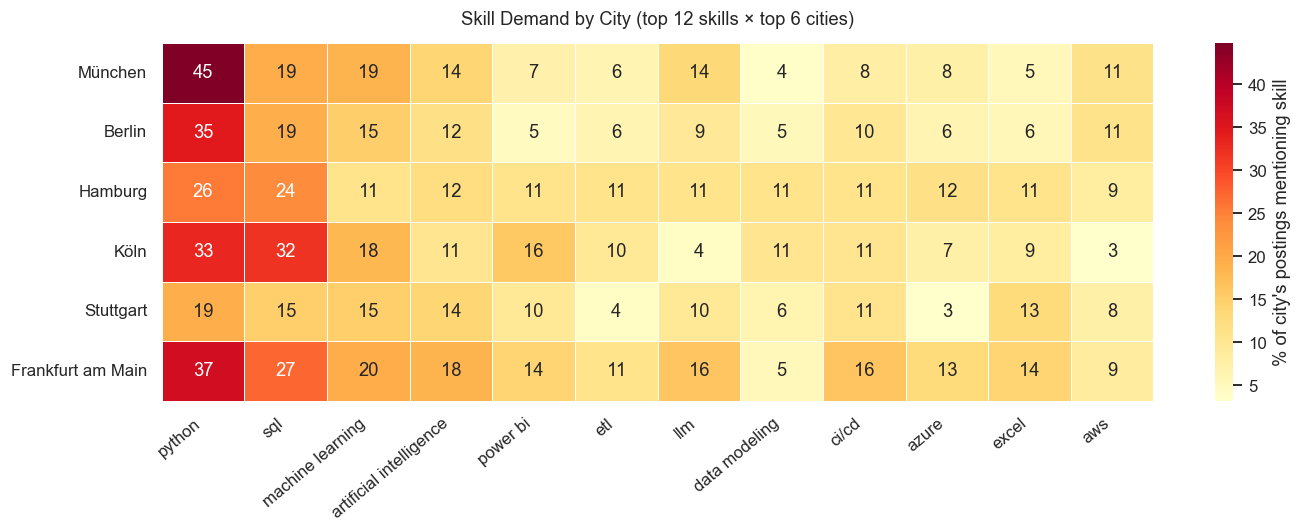

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    skill_city_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={"label": "% of city's postings mentioning skill"},
    linewidths=0.5,
    ax=ax,
)
ax.set_title(f"Skill Demand by City (top {TOP_N_SKILLS} skills × top {TOP_N_CITIES} cities)", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "skills_by_city_heatmap.png")
plt.show()

In [14]:
# Regional differentiation index: how much does each city deviate from the national skill profile?
national_skill_pct = pd.Series({
    s: 100 * (all_skills_exploded["skills_norm"] == s).sum() / len(df)
    for s in top_skills
})

differentiation = (skill_city_matrix - national_skill_pct).abs().sum(axis=1).sort_values(ascending=False)

print("Regional differentiation (sum of absolute deviations from national skill profile):")
print(differentiation.round(1).to_string())
print()
print("Higher = more atypical skill demand profile vs the national average.")

Regional differentiation (sum of absolute deviations from national skill profile):
city_norm
Frankfurt am Main    56.8
Stuttgart            45.7
München              43.0
Köln                 34.5
Hamburg              31.5
Berlin               30.4

Higher = more atypical skill demand profile vs the national average.


## 8. Role Mix by City

**Question:** Do different cities specialize in different role types? Is Munich ML-heavy? Is Frankfurt analyst-heavy?

We use the same `hauptberuf`-based role mapping as notebook 1 so the role definitions stay consistent across the analysis. Cities are restricted to top 8 by volume.

In [15]:
HAUPTBERUF_TO_ROLE = {
    "Data Scientist": "Data Scientist",
    "Datenwissenschaftler/in": "Data Scientist",
    "Wissenschaftliche/r Mitarbeiter/in": "Data Scientist",
    "Data-Analyst/in": "Data Analyst",
    "Business-Analyst/in": "Data Analyst",
    "Data-Warehouse-Analyst/in": "Data Analyst",
    "Data Engineer": "Data Engineer",
    "Datenbankentwickler/in": "Data Engineer",
    "Cloud-Architect": "Data Engineer",
    "Machine Learning Engineer": "ML Engineer",
    "KI-Engineer": "ML Engineer",
    "Business-Intelligence-Consultant": "BI / Analytics",
    "Controller/in": "BI / Analytics",
}

df["role"] = df["hauptberuf"].map(HAUPTBERUF_TO_ROLE).fillna("Not a core data role")

TOP_N_CITIES_ROLE = 8
top_cities_role = city_counts.head(TOP_N_CITIES_ROLE).index.tolist()
df_role_geo = df[
    df["city_norm"].isin(top_cities_role)
    & (df["role"] != "Not a core data role")
].copy()

role_mix = pd.crosstab(
    df_role_geo["city_norm"], df_role_geo["role"], normalize="index"
) * 100
role_mix = role_mix.reindex(top_cities_role)

# Order columns by total volume for visual consistency
role_order = df_role_geo["role"].value_counts().index.tolist()
role_mix = role_mix[role_order]
role_mix.round(1)

role,Data Engineer,Data Analyst,Data Scientist,BI / Analytics,ML Engineer
city_norm,,,,,
München,25.5,25.5,30.9,9.1,9.1
Berlin,34.4,21.3,19.7,8.2,16.4
Hamburg,48.0,24.0,12.0,8.0,8.0
Köln,38.1,19.0,14.3,14.3,14.3
Stuttgart,40.9,22.7,18.2,13.6,4.5
Frankfurt am Main,21.4,35.7,25.0,10.7,7.1
Düsseldorf,36.7,36.7,6.7,13.3,6.7
Bremen,7.1,35.7,35.7,14.3,7.1


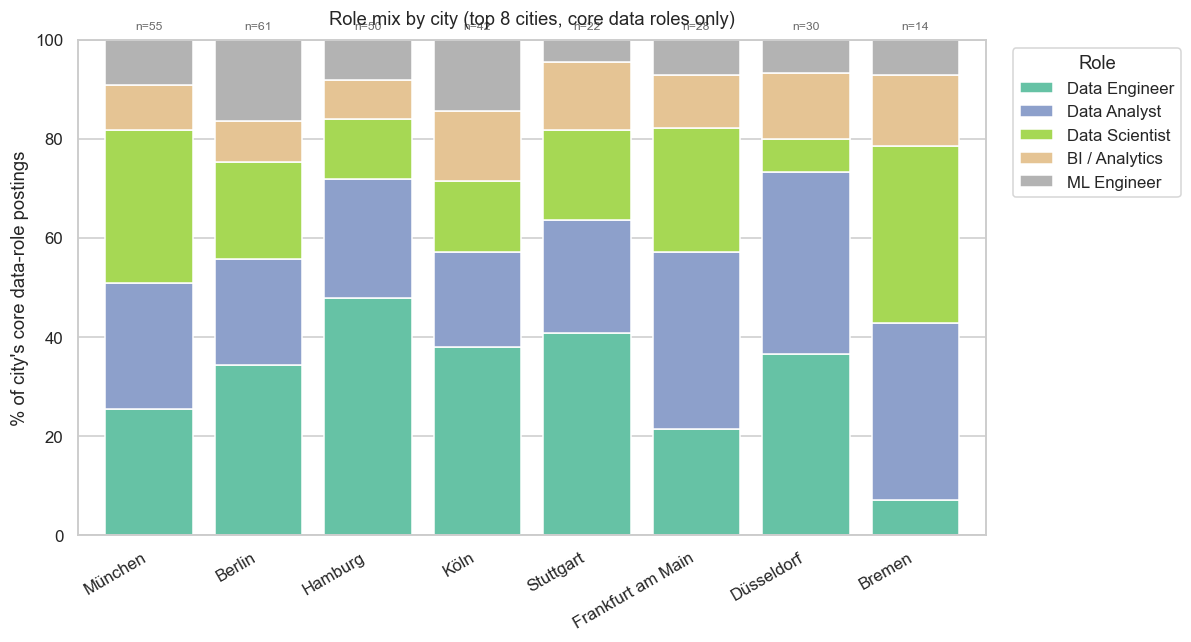

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
role_mix.plot(kind="bar", stacked=True, colormap="Set2", ax=ax, width=0.8)
ax.set_ylabel("% of city's core data-role postings")
ax.set_title(f"Role mix by city (top {TOP_N_CITIES_ROLE} cities, core data roles only)", pad=10)
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
ax.legend(title="Role", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 100)

for i, city in enumerate(top_cities_role):
    n_core = (df_role_geo["city_norm"] == city).sum()
    ax.text(i, 102, f"n={n_core}", ha="center", fontsize=8, color="dimgray")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "role_mix_by_city.png")
plt.show()

**Notes for the writeup:**

- Compare the role mix bar for each city. Which cities are unusually heavy in Data Engineering? In Data Analysis? In ML?
- The n on top of each bar matters — small samples make the percentages volatile, so flag any city with n < 50 in your post.
- A city with a sharply different role mix from the others is a candidate for your "regional specialization" finding.

## Cleanup

In [17]:
conn.close()
print("Closed DuckDB connection.")

Closed DuckDB connection.
